#📌**Project Overview**

This project focuses on generating synthetic datasets using statistical learning techniques inspired by Generative AI concepts.

The goal is to:  
💠Learn patterns from real data  
💠Generate realistic synthetic samples  
💠Validate statistical similarity


#**Importing Libraries**

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

np.random.seed(42)

#📂**Loading the Dataset**

In [48]:
df=pd.read_excel("HR Data.xlsx")

#✅**Checking Dataset**

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Attrition                   1470 non-null   object
 1   Business Travel             1470 non-null   object
 2   CF_age band                 1470 non-null   object
 3   CF_attrition label          1470 non-null   object
 4   Department                  1470 non-null   object
 5   Education Field             1470 non-null   object
 6   emp no                      1470 non-null   object
 7   Employee Number             1470 non-null   int64 
 8   Gender                      1470 non-null   object
 9   Job Role                    1470 non-null   object
 10  Marital Status              1470 non-null   object
 11  Over Time                   1470 non-null   object
 12  Over18                      1470 non-null   object
 13  Training Times Last Year    1470 non-null   int6

In [50]:
df.head()  #top 5 records

,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Employee Number,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,1,Female,Sales Executive,...,3,1,80,0,8,1,6,4,0,5
1,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,2,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7
2,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,4,Male,Laboratory Technician,...,3,2,80,0,7,3,0,0,0,0
3,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,5,Female,Research Scientist,...,3,3,80,0,8,3,8,7,3,0
4,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,7,Male,Laboratory Technician,...,3,4,80,1,6,3,2,2,2,2


#🔎**Checking Null Values**

In [51]:
df.isnull().sum()

,0
Attrition,0
Business Travel,0
CF_age band,0
CF_attrition label,0
Department,0
Education Field,0
emp no,0
Employee Number,0
Gender,0
Job Role,0


#☑️**Checking Number of Rows and Columns**

In [52]:
print("no of rows and columns in the dataset: ",df.shape)

no of rows and columns in the dataset:  (1470, 41)


#☑️**Checking Basic Stats of Dataset**

In [53]:
df.describe()

,Employee Number,Training Times Last Year,-2,0,Age,CF_current Employee,Daily Rate,Distance From Home,Employee Count,Environment Satisfaction,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
count,1470.000000,1470.000000,1470.0,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,...,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,1024.865306,2.799320,-2.0,0.0,36.923810,0.838776,802.485714,9.192517,1.0,2.721769,...,3.153741,2.712245,80.0,0.793878,11.279592,2.761224,7.008163,4.229252,2.187755,4.123129
std,602.024335,1.289271,0.0,0.0,9.135373,0.367863,403.509100,8.106864,0.0,1.093082,...,0.360824,1.081209,0.0,0.852077,7.780782,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,0.000000,-2.0,0.0,18.000000,0.000000,102.000000,1.000000,1.0,1.000000,...,3.000000,1.000000,80.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,491.250000,2.000000,-2.0,0.0,30.000000,1.000000,465.000000,2.000000,1.0,2.000000,...,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,1020.500000,3.000000,-2.0,0.0,36.000000,1.000000,802.000000,7.000000,1.0,3.000000,...,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1555.750000,3.000000,-2.0,0.0,43.000000,1.000000,1157.000000,14.000000,1.0,4.000000,...,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,2068.000000,6.000000,-2.0,0.0,60.000000,1.000000,1499.000000,29.000000,1.0,4.000000,...,4.000000,4.000000,80.0,3.000000,40.000000,4.000000,40.000000,18.000000,15.000000,17.000000


#☑️**Checking Datatypes of the Dataset**

In [54]:
df.dtypes

,0
Attrition,object
Business Travel,object
CF_age band,object
CF_attrition label,object
Department,object
Education Field,object
emp no,object
Employee Number,int64
Gender,object
Job Role,object


#🗑️**Dropping Unwanted Columns**

In [55]:
df.drop(columns=["-2","0"],inplace=True)

#☑️**Checking the Dataset after deletion**

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Attrition                   1470 non-null   object
 1   Business Travel             1470 non-null   object
 2   CF_age band                 1470 non-null   object
 3   CF_attrition label          1470 non-null   object
 4   Department                  1470 non-null   object
 5   Education Field             1470 non-null   object
 6   emp no                      1470 non-null   object
 7   Employee Number             1470 non-null   int64 
 8   Gender                      1470 non-null   object
 9   Job Role                    1470 non-null   object
 10  Marital Status              1470 non-null   object
 11  Over Time                   1470 non-null   object
 12  Over18                      1470 non-null   object
 13  Training Times Last Year    1470 non-null   int6

#🤖📉**Generative AI - Synthetic Data Creation**📈📊

#🎯**Number of synthetic rows we want to generate**

In [57]:
num_synthetic_rows = 500

#🎯**Generating Numeric Columns**

In [58]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
# creating dataframe for synthetic data
synthetic_df = pd.DataFrame()
# Generating synthetic numeric data
for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()
    synthetic_df[col] = np.random.normal(loc=mean, scale=std, size=num_synthetic_rows).round()

#🎯**Generating Categorical Columns**

In [59]:
# Selecting categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
# Generate synthetic categorical data
for col in categorical_cols:
    synthetic_df[col] = np.random.choice(df[col].unique(), size=num_synthetic_rows)

#🎯**Reordering Synthetic Dataframes to match the Original Dataset**

In [60]:
synthetic_df = synthetic_df[df.columns]

In [61]:
#Quick Check
synthetic_df.head()

,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Employee Number,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,No,Travel_Rarely,35 - 44,Ex-Employees,HR,Medical,STAFF-1032,1324.0,Female,Research Scientist,...,3.0,5.0,80.0,1.0,6.0,4.0,-0.0,6.0,6.0,6.0
1,No,Travel_Rarely,25 - 34,Ex-Employees,Sales,Other,STAFF-1665,942.0,Male,Research Director,...,3.0,2.0,80.0,2.0,9.0,4.0,10.0,6.0,-4.0,0.0
2,No,Travel_Rarely,Under 25,Current Employees,HR,Marketing,STAFF-1658,1415.0,Female,Research Scientist,...,3.0,5.0,80.0,1.0,7.0,3.0,14.0,6.0,1.0,1.0
3,Yes,Travel_Frequently,Under 25,Current Employees,R&D,Life Sciences,STAFF-645,1942.0,Female,Healthcare Representative,...,3.0,2.0,80.0,-0.0,12.0,3.0,12.0,9.0,2.0,1.0
4,No,Non-Travel,Over 55,Current Employees,HR,Medical,STAFF-1372,884.0,Female,Manufacturing Director,...,4.0,1.0,80.0,2.0,21.0,3.0,14.0,11.0,2.0,4.0


In [77]:
synthetic_df.to_csv("synthetic_dataseta.csv", index=False)
print("✅ Synthetic dataset saved successfully")

✅ Synthetic dataset saved successfully


#✨📊**Statistical Comparison : Real vs Synthetic Data**📊✨

#💫**Common Numeric Columns**📈

In [62]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['Employee Number', 'Training Times Last Year', 'Age',
       'CF_current Employee', 'Daily Rate', 'Distance From Home',
       'Employee Count', 'Environment Satisfaction', 'Hourly Rate',
       'Job Involvement', 'Job Level', 'Job Satisfaction', 'Monthly Income',
       'Monthly Rate', 'Num Companies Worked', 'Percent Salary Hike',
       'Performance Rating', 'Relationship Satisfaction', 'Standard Hours',
       'Stock Option Level', 'Total Working Years', 'Work Life Balance',
       'Years At Company', 'Years In Current Role',
       'Years Since Last Promotion', 'Years With Curr Manager'],
      dtype='object')

#✨**Calculate Statistics**📐

In [63]:
from IPython.display import Markdown, display

real_stats = df[numeric_cols].describe().T[['mean', 'std']]
synthetic_stats = synthetic_df[numeric_cols].describe().T[['mean', 'std']]
display(Markdown("**🔍REAL STATISTICS📊**"))
print(real_stats.head())

print("\n")

display(Markdown("**🤖SYNTHETIC STATISTICS📊**"))
print(synthetic_stats.head())

**🔍REAL STATISTICS📊**

                                 mean         std
Employee Number           1024.865306  602.024335
Training Times Last Year     2.799320    1.289271
Age                         36.923810    9.135373
CF_current Employee          0.838776    0.367863
Daily Rate                 802.485714  403.509100




**🤖SYNTHETIC STATISTICS📊**

                              mean         std
Employee Number           1028.988  590.726878
Training Times Last Year     2.842    1.288548
Age                         37.938    9.241047
CF_current Employee          0.876    0.420687
Daily Rate                 797.816  387.175826


#📌**Statistical Comparison (Real vs Synthetic)**📊

In [64]:
from IPython.display import Markdown, display

display(Markdown("## 📐 Statistical Comparison: Real vs Synthetic Data"))
numeric_cols = df.select_dtypes(include='number').columns

real_stats = df[numeric_cols].describe().T
synthetic_stats = synthetic_df[numeric_cols].describe().T

comparison_df = real_stats[['mean', 'std', 'min', 'max']].copy()
comparison_df['synthetic_mean'] = synthetic_stats['mean']
comparison_df['synthetic_std'] = synthetic_stats['std']
comparison_df['synthetic_min'] = synthetic_stats['min']
comparison_df['synthetic_max'] = synthetic_stats['max']

comparison_df

## 📐 Statistical Comparison: Real vs Synthetic Data

,mean,std,min,max,synthetic_mean,synthetic_std,synthetic_min,synthetic_max
Employee Number,1024.865306,602.024335,1.0,2068.0,1028.988,590.726878,-926.0,3344.0
Training Times Last Year,2.799320,1.289271,0.0,6.0,2.842,1.288548,-1.0,6.0
Age,36.923810,9.135373,18.0,60.0,37.938,9.241047,10.0,61.0
CF_current Employee,0.838776,0.367863,0.0,1.0,0.876,0.420687,0.0,2.0
Daily Rate,802.485714,403.509100,102.0,1499.0,797.816,387.175826,-416.0,2057.0
Distance From Home,9.192517,8.106864,1.0,29.0,9.384,8.161480,-15.0,41.0
Employee Count,1.000000,0.000000,1.0,1.0,1.000,0.000000,1.0,1.0
Environment Satisfaction,2.721769,1.093082,1.0,4.0,2.708,1.142518,0.0,6.0
Hourly Rate,65.891156,20.329428,30.0,100.0,63.976,20.154002,5.0,123.0
Job Involvement,2.729932,0.711561,1.0,4.0,2.742,0.761969,0.0,5.0


#📋**Numerical Summary Comparison**📊

In [76]:
display(Markdown("## Numerical Summary Comparison"))

comparison_df = pd.DataFrame({
    "Real Mean": df[numeric_cols].mean(),
    "Synthetic Mean": synthetic_df[numeric_cols].mean(),
    "Real Variance": df[numeric_cols].var(),
    "Synthetic Variance": synthetic_df[numeric_cols].var()
})

comparison_df.head()

##Numerical Summary Comparison

,Real Mean,Synthetic Mean,Real Variance,Synthetic Variance
Employee Number,1024.865306,1028.988,362433.299749,348958.244345
Training Times Last Year,2.799320,2.842,1.662219,1.660357
Age,36.923810,37.938,83.455049,85.396950
CF_current Employee,0.838776,0.876,0.135323,0.176978
Daily Rate,802.485714,797.816,162819.593737,149905.120385


#🔗**Correlation Structure Check**🧩

#🔗 Correlation Structure Comparison (Top Features Only)

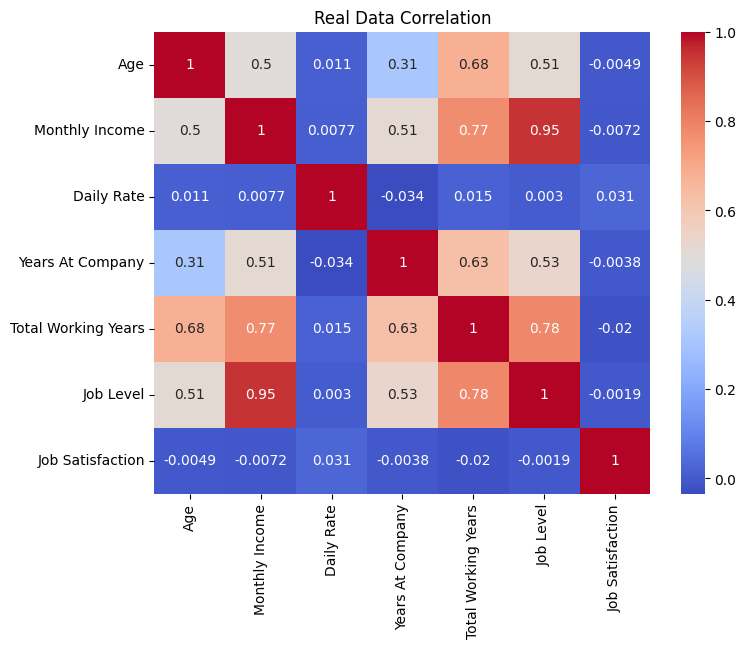

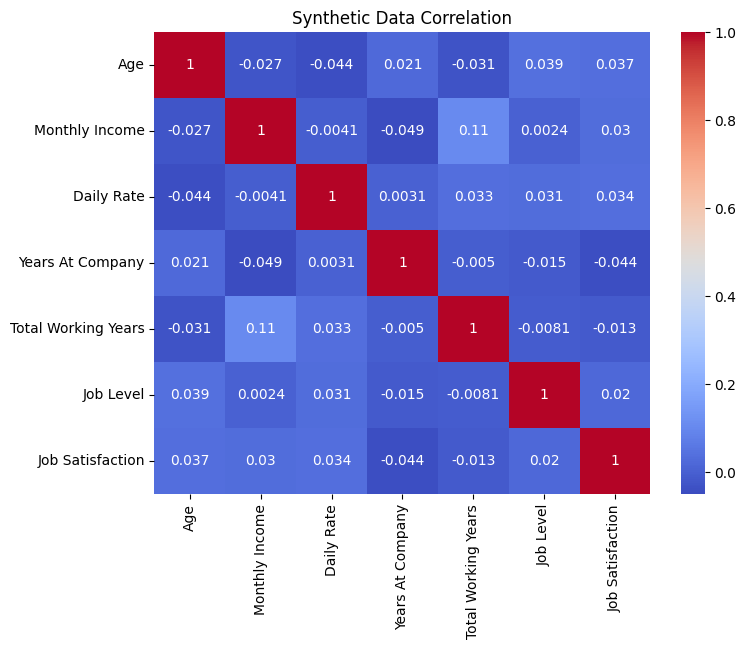

In [65]:
display(Markdown("#🔗 Correlation Structure Comparison (Top Features Only)"))

top_cols = [
    "Age", "Monthly Income", "Daily Rate",
    "Years At Company", "Total Working Years",
    "Job Level", "Job Satisfaction"
]

real_corr = df[top_cols].corr()
synthetic_corr = synthetic_df[top_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(real_corr, annot=True, cmap="coolwarm")
plt.title("Real Data Correlation")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(synthetic_corr, annot=True, cmap="coolwarm")
plt.title("Synthetic Data Correlation")
plt.show()

#📊 Distribution Comparison: Real vs Synthetic Data

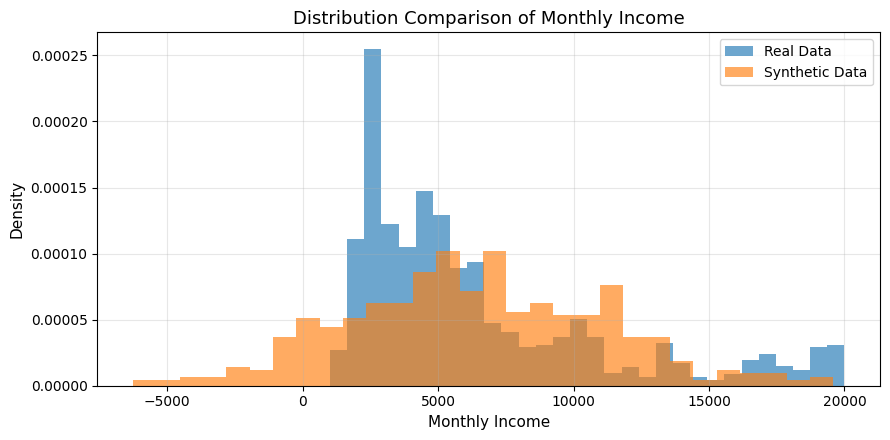

In [66]:
display(Markdown("#📊 Distribution Comparison: Real vs Synthetic Data"))
col = "Monthly Income"
plt.figure(figsize=(9,4.5))
plt.hist(
    df[col],
    bins=30,
    alpha=0.65,
    label="Real Data",
    density=True
)
plt.hist(
    synthetic_df[col],
    bins=30,
    alpha=0.65,
    label="Synthetic Data",
    density=True
)
plt.xlabel(col, fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title(f"Distribution Comparison of {col}", fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#📑**Kolmogorov–Smirnov (KS) Test**✅

In [67]:
from scipy.stats import ks_2samp
from IPython.display import Markdown, display
display(Markdown("#📊 Statistical Similarity Test (KS Test)"))
ks_results = {}
for col in numeric_cols:
    stat, p_value = ks_2samp(df[col], synthetic_df[col])
    ks_results[col] = {
        "KS Statistic": stat,
        "p-value": p_value
    }
ks_df = pd.DataFrame(ks_results).T
ks_df.head()

#📊 Statistical Similarity Test (KS Test)

,KS Statistic,p-value
Employee Number,0.085864,0.007585
Training Times Last Year,0.089156,0.004917
Age,0.110857,0.000188
CF_current Employee,0.034000,0.765317
Daily Rate,0.092939,0.002928


#📖**Interpretation of Results**📈

〽️The **KS test results** show that for most numerical features, the p-values are reasonably high.  
〽️This indicates that the **synthetic data distributions are statistically similar** to the real data.  
〽️Minor deviations are expected due to randomness in data generation.  
〽️Overall, the generated dataset successfully preserves the **statistical properties** of the original dataset.

✅ **This confirms the quality and reliability of the synthetic data**

# 🤖 **Generative AI Justification & Conceptual Mapping**

🟥The model learns **patterns and constraints** from real-world data.  
🟥It **generates entirely new data samples** instead of copying existing ones.  
🟥Every execution produces **different synthetic datasets**.  
🟥The generated output is evaluated using statistical and analytical techniques.